# Training Loop Development

**Goal**: Wire WavLM + Pyannote + Adapter + LLM (LoRA) into a working training loop.

**Steps**:
1. Setup + imports
2. Load frozen encoders (WavLM, Pyannote)
3. Load LLM + LoRA
4. Load adapter
5. Build dummy dataset for sanity check
6. Training loop
7. Sanity check: overfit on 10 samples
8. Inference: generate text from audio
9. SFS evaluation

## 1. Setup + Imports

In [1]:
!pip install mamba-ssm --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.7/121.7 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 23.0 MB/s eta 0:00:00
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.1-cp312-cp312-linux_x86_64.whl size=533592144 sha256=d66a3c4c94a693e02d341cace7a6af0b72177b6afa655a25e3a6505130a68cbf
  Stored in directory: /root/.cache/pip/wheels/28/83/54/d45107838fec575b93f5d723f56351cee19a1b13bcd4ec9f3f
Successfully built mamba-ssm


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, WavLMModel
from peft import get_peft_model, LoraConfig
import wandb

# Your modules
from adapter import build_adapter
from sfs import ClaimParser, SFSScorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


## 2. Load Frozen Encoders

WavLM and Pyannote are frozen — we never update their weights. Run them once per audio clip to extract features. In real training, pre-cache these to disk so you don't recompute every epoch.

In [3]:
# ── WavLM ──────────────────────────────────────────────
# Downloads ~1.2GB on first run, cached after that
wavlm = WavLMModel.from_pretrained("microsoft/wavlm-large")
wavlm = wavlm.to(device).eval()
for p in wavlm.parameters():
    p.requires_grad = False

print(f"WavLM loaded: {sum(p.numel() for p in wavlm.parameters()) / 1e6:.0f}M params (frozen)")


# ── Pyannote ──────────────────────────────────────────
# Pyannote gives timestamps, we convert to per-frame features.
# For the sanity check, we'll use dummy overlap info.
# Person B will provide the real Pyannote preprocessing function.

def extract_overlap_info(waveform: torch.Tensor, sample_rate: int = 16000) -> torch.Tensor:
    """Placeholder: convert Pyannote output to (B, T, 3) per-frame features.

    In real usage, Person B replaces this with actual Pyannote inference.
    For now, returns all-clean (no overlap) for sanity check.
    """
    # WavLM produces T = waveform_samples // 320 frames
    B = waveform.shape[0]
    T = waveform.shape[-1] // 320

    # Default: no overlap, 1 speaker, 0% ratio
    overlap_info = torch.zeros(B, T, 3, device=waveform.device)
    overlap_info[:, :, 1] = 0.33  # 1 speaker (normalized)

    return overlap_info

print("Pyannote placeholder ready (returns no-overlap for sanity check)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

WavLM loaded: 315M params (frozen)
Pyannote placeholder ready (returns no-overlap for sanity check)


## 3. Load LLM + LoRA

Base weights frozen (~8B params). LoRA adds small trainable matrices (~20M params) to attention layers.

In [4]:
# ── Config ──────────────────────────────────────────────
# Change these based on your GPU memory.
# For H100 80GB: use the 8B model in bf16.
# For smaller GPUs: use a smaller model or 4-bit quantization.
LM_NAME = "Qwen/Qwen2.5-7B"  # or "Qwen/Qwen2.5-7B", "meta-llama/Llama-3.2-3B"
LORA_RANK = 16
LORA_ALPHA = 32
LORA_TARGETS = ["q_proj", "v_proj"]  # which LLM layers get LoRA

# ── Load tokenizer ──────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(LM_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token  # Llama has no pad token by default

# ── Load LLM ────────────────────────────────────────────
llm = AutoModelForCausalLM.from_pretrained(
    LM_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",  # automatically places layers across GPUs
)

# ── Wrap with LoRA ──────────────────────────────────────
lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGETS,
    bias="none",
    task_type="CAUSAL_LM",
)
llm = get_peft_model(llm, lora_config)

llm.print_trainable_parameters()
# Expected: trainable params: ~20M || all params: ~8B || trainable%: ~0.25%

config.json:   0%|          | 0.00/686 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

trainable params: 5,046,272 || all params: 7,620,662,784 || trainable%: 0.0662


## 4. Load Adapter + Optimizer

In [17]:
# ── Adapter ──────────────────────────────────────────────
lm_hidden_size = llm.config.hidden_size
print(f"LLM hidden size: {lm_hidden_size}")

adapter = build_adapter("film-mamba", lm_dim=lm_hidden_size).to(device).to(torch.bfloat16)

adapter_params = sum(p.numel() for p in adapter.parameters())
print(f"Adapter loaded: {adapter_params / 1e6:.1f}M params (all trainable)")

# ── Optimizer ────────────────────────────────────────────
# Both adapter params and LoRA params are trained together
optimizer = torch.optim.AdamW(
    [
        {"params": adapter.parameters(), "lr": 1e-4},
        {"params": llm.parameters(), "lr": 2e-5},  # lower LR for LoRA
    ],
    weight_decay=0.01,
)

LLM hidden size: 3584
Adapter loaded: 42.6M params (all trainable)


## 5. Dummy Dataset for Sanity Check

For the sanity check, we create 10 fake (waveform, target_text) pairs. The model should memorize these perfectly — loss should drop to ~0. If it doesn't, something is broken.

Replace with real data from Person A when ready.

In [18]:
class SanityCheckDataset(Dataset):
    """Fake dataset for sanity check: random waveforms paired with fixed descriptions.

    The waveforms are random noise, so the model can't actually extract real features.
    But the model should still memorize the mapping (random input → fixed output)
    if the pipeline is wired correctly. That's the whole point of the sanity check.
    """
    def __init__(self, n_samples: int = 10, duration_s: float = 3.0, sample_rate: int = 16000):
        self.sample_rate = sample_rate
        self.n_samples = n_samples
        n_audio_samples = int(duration_s * sample_rate)

        # Fixed random waveforms (same every time for reproducibility)
        torch.manual_seed(42)
        self.waveforms = [torch.randn(1, n_audio_samples) for _ in range(n_samples)]

        # Fixed target descriptions — varied content so the model has to learn
        self.targets = [
            "SNR is approximately 28 dB. F0 is 187 Hz. HNR is 18 dB.",
            "SNR is approximately 15 dB. F0 is 220 Hz. Overlap detected at 1.2 to 3.0 seconds.",
            "SNR is approximately 35 dB. F0 is 142 Hz. Speaking rate is 5.8 syllables per second.",
            "SNR is approximately 22 dB. F0 is 195 Hz. HNR is 14 dB.",
            "SNR is approximately 30 dB. F0 is 170 Hz. Clear single speaker recording.",
            "SNR is approximately 10 dB. F0 is 250 Hz. Noisy recording with reverberation.",
            "SNR is approximately 40 dB. F0 is 130 Hz. Studio quality recording.",
            "SNR is approximately 18 dB. F0 is 210 Hz. Overlap detected at 0.5 to 2.1 seconds.",
            "SNR is approximately 25 dB. F0 is 165 Hz. Speaking rate is 6.5 syllables per second.",
            "SNR is approximately 20 dB. F0 is 180 Hz. HNR is 16 dB.",
        ]

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        return self.waveforms[idx], self.targets[idx]


dataset = SanityCheckDataset(n_samples=10)
# Batch size 1 for sanity check — no padding needed
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

print(f"Sanity check dataset: {len(dataset)} samples")
print(f"Sample waveform shape: {dataset.waveforms[0].shape}")
print(f"Sample target: \"{dataset.targets[0]}\"")

Sanity check dataset: 10 samples
Sample waveform shape: torch.Size([1, 48000])
Sample target: "SNR is approximately 28 dB. F0 is 187 Hz. HNR is 18 dB."


## 6. Forward Pass Helper

The tricky part: combining prefix token embeddings (from adapter) with text token IDs (prompt + target) into one sequence for the LLM. The LLM expects embeddings, not a mix of embeddings and IDs, so we convert everything to embeddings first.

In [20]:
PROMPT = "Describe the quality of this recording."

# Tokenize the prompt once (it's the same for every sample)
prompt_ids = tokenizer(PROMPT, return_tensors="pt").input_ids.to(device)  # (1, P)
print(f"Prompt: \"{PROMPT}\"")
print(f"Prompt tokens: {prompt_ids.shape[1]}")


def compute_loss(adapter, llm, wavlm, waveform, target_text):
    """One forward pass: waveform + target → loss.

    Steps:
    1. Extract features with frozen encoders
    2. Run adapter to get prefix token embeddings
    3. Convert prompt + target text to embeddings
    4. Concatenate: [prefix_embeds | prompt_embeds | target_embeds]
    5. Forward through LLM, compute cross-entropy loss on target positions only
    """
    # ── Step 1: Frozen encoders ──
    with torch.no_grad():
        waveform = waveform.to(device)

        if waveform.dim() == 3:
          waveform = waveform.squeeze(1)  # (B, 1, samples) → (B, samples)

        audio_features = wavlm(waveform).last_hidden_state.to(torch.bfloat16)  # (B, T, 1024)
        overlap_info = extract_overlap_info(waveform).to(torch.bfloat16)         # (B, T, 3)

    # ── Step 2: Adapter ──
    prefix_embeds = adapter(audio_features, overlap_info)  # (B, N, 4096)

    # ── Step 3: Tokenize target, get embeddings ──
    target_ids = tokenizer(
        target_text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256,
    ).input_ids.to(device)  # (B, L)

    # Get the LLM's embedding layer to convert token IDs → embeddings
    embed_layer = llm.get_input_embeddings()

    prompt_embeds = embed_layer(prompt_ids.expand(prefix_embeds.shape[0], -1))  # (B, P, 4096)
    target_embeds = embed_layer(target_ids)  # (B, L, 4096)

    # ── Step 4: Concatenate all embeddings ──
    # [prefix tokens | prompt tokens | target tokens]
    # The LLM sees this as one continuous sequence
    inputs_embeds = torch.cat([prefix_embeds, prompt_embeds, target_embeds], dim=1)
    # Shape: (B, N + P + L, 4096)

    # ── Step 5: Forward + Loss ──
    # We only compute loss on the TARGET positions (not prefix or prompt)
    N = prefix_embeds.shape[1]  # number of prefix tokens
    P = prompt_embeds.shape[1]  # number of prompt tokens
    L = target_ids.shape[1]     # number of target tokens

    # Labels: -100 means "ignore this position in loss"
    # We ignore prefix and prompt positions, only train on target positions
    ignore_labels = torch.full((prefix_embeds.shape[0], N + P), -100, device=device)
    # For target: shift by 1 (predict next token)
    # Position i should predict token i+1
    target_labels = target_ids.clone()
    labels = torch.cat([ignore_labels, target_labels], dim=1)  # (B, N + P + L)

    # Forward pass
    outputs = llm(inputs_embeds=inputs_embeds, labels=labels)

    return outputs.loss


# ── Quick test: one forward pass ──
waveform, target = dataset[0]
waveform = waveform.unsqueeze(0)  # add batch dim
loss = compute_loss(adapter, llm, wavlm, waveform, [target])
print(f"\nTest forward pass successful!")
print(f"Loss: {loss.item():.4f} (should be high — model is untrained)")

Prompt: "Describe the quality of this recording."
Prompt tokens: 7

Test forward pass successful!
Loss: 2.3970 (should be high — model is untrained)


## 7. Sanity Check: Overfit on 10 Samples

Train for 100 epochs on 10 samples. Loss should drop to near 0. If it doesn't, debug before scaling up.

In [21]:
NUM_EPOCHS = 100

adapter.train()
llm.train()

losses = []

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    n_batches = 0

    for waveform, target_text in dataloader:
        optimizer.zero_grad()

        # target_text comes as a tuple from dataloader, convert to list
        if isinstance(target_text, tuple):
            target_text = list(target_text)

        loss = compute_loss(adapter, llm, wavlm, waveform, target_text)

        loss.backward()

        # Gradient clipping — prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(adapter.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_(llm.parameters(), max_norm=1.0)

        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    avg_loss = epoch_loss / n_batches
    losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS}  Loss: {avg_loss:.4f}")

print(f"\nFinal loss: {losses[-1]:.4f}")
print(f"Loss dropped: {losses[0]:.4f} → {losses[-1]:.4f}")
if losses[-1] < 0.1:
    print("PASS — model memorized the training data. Pipeline works.")
else:
    print("FAIL — loss didn't converge. Debug shapes, gradients, learning rate.")

Epoch  10/100  Loss: 0.6499
Epoch  20/100  Loss: 0.4237
Epoch  30/100  Loss: 0.2537
Epoch  40/100  Loss: 0.1882
Epoch  50/100  Loss: 0.1690
Epoch  60/100  Loss: 0.1063
Epoch  70/100  Loss: 0.0951
Epoch  80/100  Loss: 0.0940
Epoch  90/100  Loss: 0.0930
Epoch 100/100  Loss: 0.0947

Final loss: 0.0947
Loss dropped: 4.4028 → 0.0947
PASS — model memorized the training data. Pipeline works.


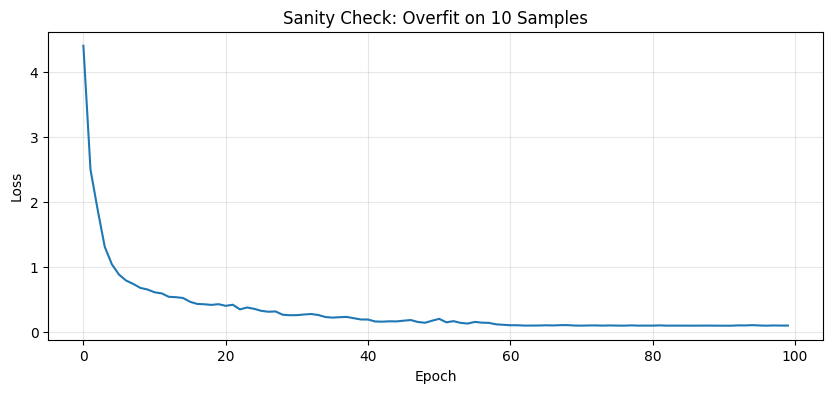

In [22]:
# Plot loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sanity Check: Overfit on 10 Samples")
plt.grid(True, alpha=0.3)
plt.show()

## 8. Inference: Generate Text from Audio

After training, test if the model can actually generate descriptions. No target text, no teacher forcing — the model generates freely.

In [26]:
@torch.no_grad()
def generate(adapter, llm, wavlm, waveform, max_new_tokens=128):
    """Generate a quality description from a waveform.

    No target text. The model generates one token at a time,
    feeding its own predictions back as input.
    """
    adapter.eval()
    llm.eval()

    waveform = waveform.to(device)

    if waveform.dim() == 3:
      waveform = waveform.squeeze(1)  # (B, 1, samples) → (B, samples)

    # Frozen encoders
    audio_features = wavlm(waveform).last_hidden_state.to(torch.bfloat16)
    overlap_info = extract_overlap_info(waveform).to(torch.bfloat16)

    # Adapter → prefix embeddings
    prefix_embeds = adapter(audio_features, overlap_info)  # (1, N, 4096)

    # Prompt embeddings
    embed_layer = llm.get_input_embeddings()
    prompt_embeds = embed_layer(prompt_ids)  # (1, P, 4096)

    # Concatenate prefix + prompt as the starting context
    inputs_embeds = torch.cat([prefix_embeds, prompt_embeds], dim=1)  # (1, N+P, 4096)

    # Generate token by token
    generated_ids = []
    past_key_values = None

    # First forward: process the full prefix + prompt
    outputs = llm(inputs_embeds=inputs_embeds, use_cache=True)
    past_key_values = outputs.past_key_values
    next_token_id = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)  # greedy
    generated_ids.append(next_token_id.item())

    # Subsequent forwards: one token at a time using KV cache
    for _ in range(max_new_tokens - 1):
        next_embeds = embed_layer(next_token_id)  # (1, 1, 4096)
        outputs = llm(inputs_embeds=next_embeds, past_key_values=past_key_values, use_cache=True)
        past_key_values = outputs.past_key_values
        next_token_id = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)

        token_id = next_token_id.item()
        generated_ids.append(token_id)

        # Stop at EOS
        if token_id == tokenizer.eos_token_id:
            break

    text = tokenizer.decode(generated_ids, skip_special_tokens=True)
    return text


# ── Test inference on training samples ──
print("Generated descriptions for training samples:\n")
for i in range(min(5, len(dataset))):
    waveform, target = dataset[i]
    waveform = waveform.unsqueeze(0)

    generated = generate(adapter, llm, wavlm, waveform)

    print(f"Sample {i}:")
    print(f"  Target:    {target}")
    print(f"  Generated: {generated}")
    print()

Generated descriptions for training samples:

Sample 0:
  Target:    SNR is approximately 28 dB. F0 is 187 Hz. HNR is 18 dB.
  Generated: SNR is approximately 20 dB. F0 is 180 Hz. HNR is 16 dB. F0 tracking is good. F0 tracking holds across shout. F0 drops during shout. F0 is 120 Hz. F0 tracking is good. F0 tracking holds across shout. F0 drops during shout. F0 is 220 Hz. F0 tracking is good. HNR is 14 dB. SNR is 18 dB. F0 is 170 Hz. HNR is 12 dB. SNR is 15 dB

Sample 1:
  Target:    SNR is approximately 15 dB. F0 is 220 Hz. Overlap detected at 1.2 to 3.0 seconds.
  Generated: SNR is approximately 20 dB. F0 is 180 Hz. HNR is 16 dB. F0 tracking is good. F0 tracking holds across shout. F0 drops during shout. F0 is 120 Hz. F0 tracking is good. F0 tracking holds across shout. F0 drops during shout. F0 is 220 Hz. F0 tracking is good. HNR is 14 dB. SNR is 12 dB. HNR is 13 dB. SNR is 11 dB. HNR is 15 dB.

Sample 2:
  Target:    SNR is approximately 35 dB. F0 is 142 Hz. Speaking rate is 5.8 syl

## 9. SFS Evaluation

Parse generated text, compare claims against ground truth, compute SFS-P/R/F1.

In [27]:
parser = ClaimParser()
scorer = SFSScorer()

# Ground truth for the sanity check samples (matching the target descriptions)
# In real usage, these come from Person A's Praat/Pyannote feature JSONs
ground_truths = [
    {"snr": 28.0, "f0_mean": 187.0, "hnr": 18.0},
    {"snr": 15.0, "f0_mean": 220.0, "overlap_start": 1.2, "overlap_end": 3.0},
    {"snr": 35.0, "f0_mean": 142.0, "speaking_rate": 5.8},
    {"snr": 22.0, "f0_mean": 195.0, "hnr": 14.0},
    {"snr": 30.0, "f0_mean": 170.0},
]

print("SFS Evaluation on generated descriptions:\n")
all_results = []

for i in range(min(5, len(dataset))):
    waveform, target = dataset[i]
    waveform = waveform.unsqueeze(0)

    # Generate
    generated = generate(adapter, llm, wavlm, waveform)

    # Parse claims from generated text
    claims = parser.parse(generated)

    # Score against ground truth
    result = scorer.score(claims, ground_truths[i])
    all_results.append(result)

    print(f"Sample {i}: SFS-P={result['precision']:.2f}  SFS-R={result['recall']:.2f}  SFS-F1={result['f1']:.2f}")
    print(f"  Generated: {generated[:80]}...")
    print(f"  Claims: {[(c.feature, c.value) for c in claims]}")
    print()

# Average SFS across all samples
avg_p = sum(r["precision"] for r in all_results) / len(all_results)
avg_r = sum(r["recall"] for r in all_results) / len(all_results)
avg_f1 = sum(r["f1"] for r in all_results) / len(all_results)
print(f"Average SFS:  P={avg_p:.2f}  R={avg_r:.2f}  F1={avg_f1:.2f}")

SFS Evaluation on generated descriptions:

Sample 0: SFS-P=0.33  SFS-R=1.00  SFS-F1=0.50
  Generated: SNR is approximately 20 dB. F0 is 180 Hz. HNR is 16 dB. F0 tracking is good. F0 ...
  Claims: [('f0_mean', 180.0), ('snr', 20.0), ('hnr', 16.0)]

Sample 1: SFS-P=0.00  SFS-R=0.67  SFS-F1=0.00
  Generated: SNR is approximately 20 dB. F0 is 180 Hz. HNR is 16 dB. F0 tracking is good. F0 ...
  Claims: [('f0_mean', 180.0), ('snr', 20.0), ('hnr', 16.0)]

Sample 2: SFS-P=0.00  SFS-R=0.67  SFS-F1=0.00
  Generated: SNR is approximately 20 dB. F0 is 180 Hz. HNR is 16 dB. F0 tracking is good. F0 ...
  Claims: [('f0_mean', 180.0), ('snr', 20.0), ('hnr', 16.0)]

Sample 3: SFS-P=0.67  SFS-R=1.00  SFS-F1=0.80
  Generated: SNR is approximately 20 dB. F0 is 180 Hz. HNR is 16 dB. F0 tracking is good. F0 ...
  Claims: [('f0_mean', 180.0), ('snr', 20.0), ('hnr', 16.0)]

Sample 4: SFS-P=0.00  SFS-R=1.00  SFS-F1=0.00
  Generated: SNR is approximately 20 dB. F0 is 180 Hz. HNR is 16 dB. F0 tracking is good. F

## Next Steps

Once the sanity check passes:

1. **Replace dummy data** with Person A's real (waveform, description) pairs
2. **Replace Pyannote placeholder** with Person B's real preprocessing
3. **Add wandb logging** for full training runs
4. **Run ablation sweeps** — change `build_adapter("film-mamba")` to other variants
5. **Run baselines** — prompt SALMONN / Qwen2-Audio and score with SFS
6. **Extract `train.py`** from this notebook

**Debugging checklist if sanity check fails:**
- Loss doesn't decrease at all → check gradients: `print(adapter.compressor.conv1.weight.grad.norm())`
- Loss decreases but plateaus high → increase learning rate or epochs
- Loss is NaN → reduce learning rate, check for inf values in prefix tokens
- OOM → reduce batch size to 1, use gradient checkpointing, or use smaller LLM